# jjh

---

**Project**
- <project-name>

**Module**
- notebooks

**Author**
- Hyeok

**Created**
- 2026-03-07

**Purpose**
- TODO: EDA, Data Visualization

---


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 환경 설정
warnings.filterwarnings('ignore')
plt.rc('font', family='DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 8)
file_path = './data/preprocessed_churn_data.csv'

### EDA
데이터의 기본적인 구조와 분포를 파악하는 단계입니다.

In [31]:
df = pd.read_csv(file_path)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   churn                10127 non-null  int64  
 1   age                  10127 non-null  int64  
 2   gender               10127 non-null  int64  
 3   dependents           10127 non-null  int64  
 4   education            10127 non-null  int64  
 5   marital              10127 non-null  int64  
 6   income               10127 non-null  int64  
 7   card_type            10127 non-null  int64  
 8   relationship_months  10127 non-null  int64  
 9   product_count        10127 non-null  int64  
 10  inactive_months      10127 non-null  int64  
 11  contact_count        10127 non-null  int64  
 12  credit_limit         10127 non-null  float64
 13  revolving_balance    10127 non-null  int64  
 14  available_credit     10127 non-null  float64
 15  amount_change        10127 non-null  float64
 1

In [33]:
df.head()

,churn,age,gender,dependents,education,marital,income,card_type,relationship_months,product_count,inactive_months,contact_count,credit_limit,revolving_balance,available_credit,amount_change,transaction_amount,transaction_count,count_change,utilization_ratio
0,1,45,0,3,2,2,3,1,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,1,49,1,5,4,1,1,1,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,1,51,0,3,4,2,4,1,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,1,40,1,4,2,4,1,1,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,1,40,0,3,1,2,3,1,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [34]:
df.describe()

,churn,age,gender,dependents,education,marital,income,card_type,relationship_months,product_count,inactive_months,contact_count,credit_limit,revolving_balance,available_credit,amount_change,transaction_amount,transaction_count,count_change,utilization_ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,0.839340,46.325960,0.529081,2.346203,3.651921,1.832428,2.744544,1.083638,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,0.367235,8.016814,0.499178,1.298908,1.917002,0.855016,1.716188,0.333784,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,0.000000,26.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,1.000000,41.000000,0.000000,1.000000,2.000000,1.000000,1.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,1.000000,46.000000,1.000000,2.000000,4.000000,2.000000,2.000000,1.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,1.000000,52.000000,1.000000,3.000000,4.000000,2.000000,4.000000,1.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,1.000000,73.000000,1.000000,5.000000,7.000000,4.000000,6.000000,4.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


### 변수 간 상관관계 분석

이탈(Churn)에 영향을 미치는 핵심 변수를 식별하기 위해 전체 변수 간의 상관계수를 시각화합니다.

Text(0.5, 1.0, 'Customer Churn Correlation Analysis')

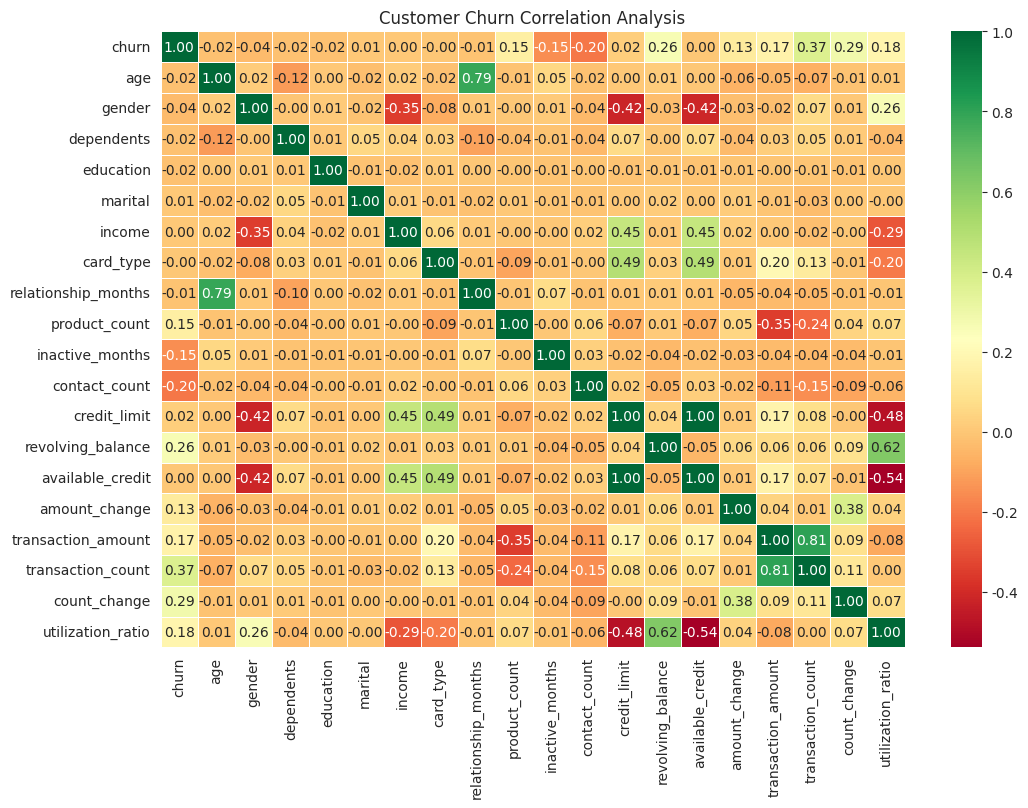

In [35]:
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5).set_title('Customer Churn Correlation Analysis')

In [36]:
# 교육, 결혼, 소득 내의 unknown 객체가 지표값을 얼마나 차지하는지, 데이터 누락의 영향력 검증
unknown_targets = {'education': 7, 'marital': 4, 'income': 6}

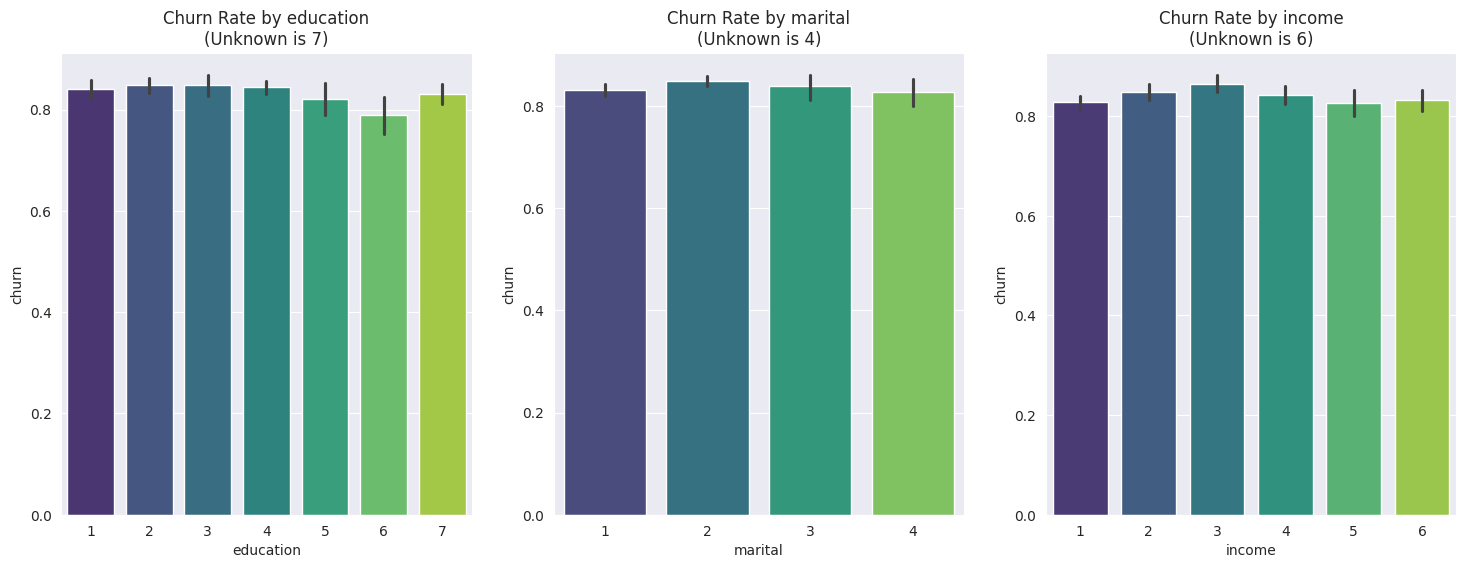

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (col, val) in enumerate(unknown_targets.items()):
    sns.barplot(x=col, y='churn', data=df, palette='viridis', ax=axes[i]).set_title(f'Churn Rate by {col}\n(Unknown is {val})')
# 결국, unknown 그룹의 인적 정보 누락 이탈의 직접적 신호라고 보기는 어려움. (잠재적 활동군)

Text(0.5, 1.0, 'Customer Count & Churn by Card Category')

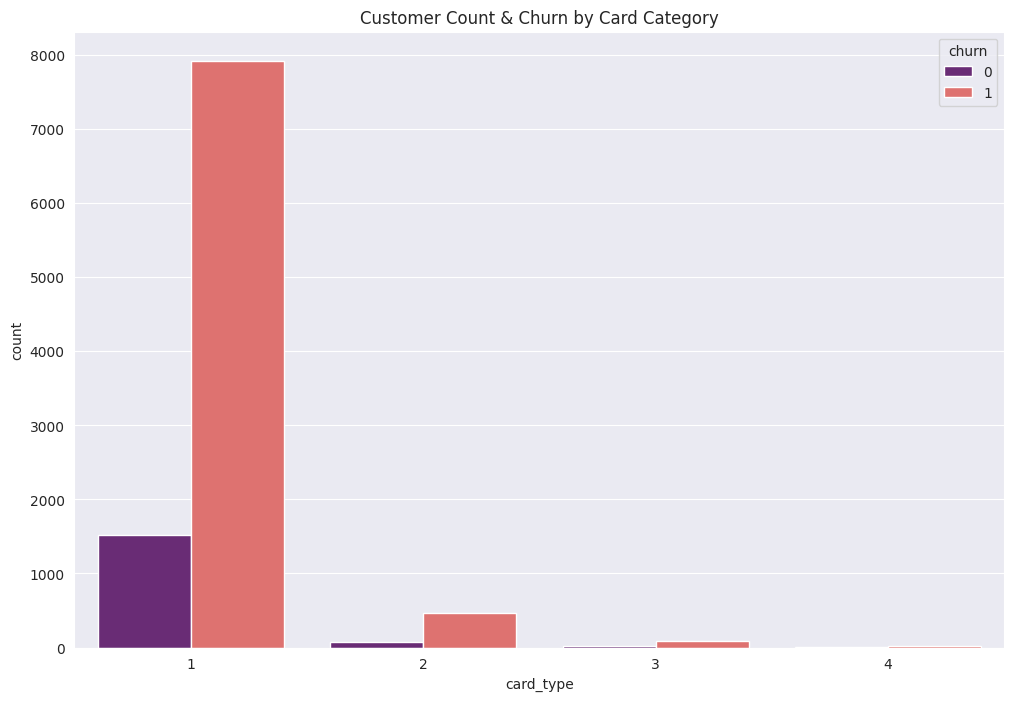

In [38]:
# 카드 등급별 고객 지표
sns.countplot(x='card_type', hue='churn', data=df, palette='magma').set_title('Customer Count & Churn by Card Category')

In [39]:
# 카드 등급과 이용 지표
df.groupby('card_type')[['transaction_amount', 'transaction_count']].mean()

,transaction_amount,transaction_count
card_type,,
1,4225.406740,64.028190
2,6590.482883,74.700901
3,7685.612069,81.517241
4,8999.750000,86.950000


In [40]:
# 소득 수준 카드 등급
pd.crosstab(df['income'], df['card_type'], normalize='index')

card_type,1,2,3,4
income,,,,
1,0.955630,0.036507,0.006740,0.001123
2,0.935754,0.055307,0.008380,0.000559
3,0.907989,0.068474,0.020685,0.002853
4,0.908795,0.076221,0.013681,0.001303
5,0.887208,0.082531,0.024759,0.005502
6,0.939748,0.047662,0.008094,0.004496


Text(0.5, 1.0, 'Transaction Count Distribution by Churn Status')

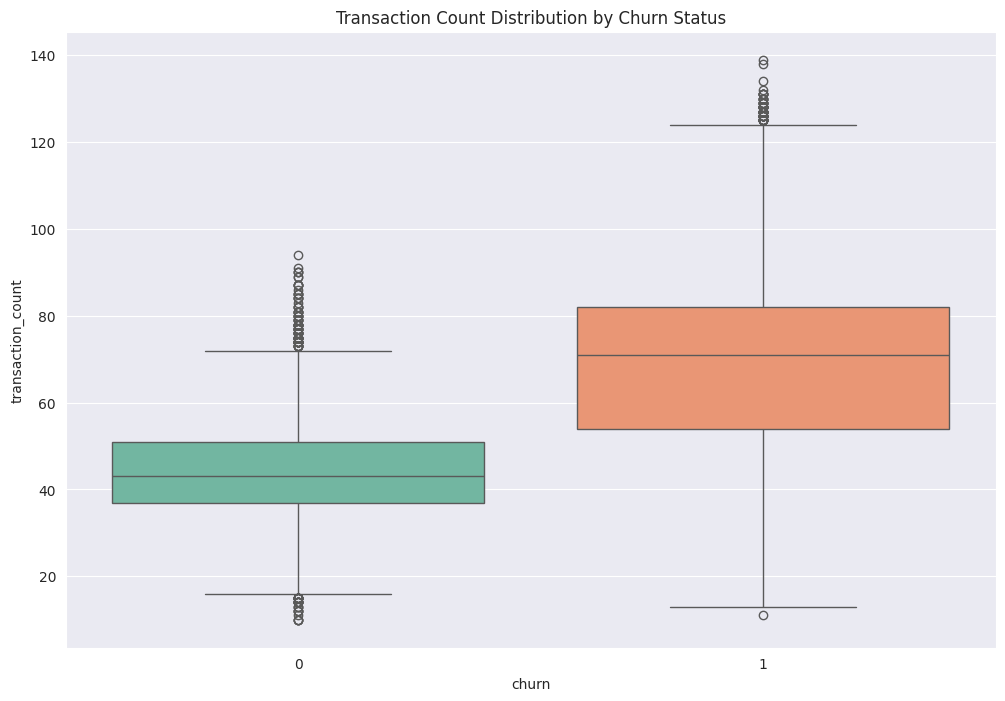

In [41]:
# 이탈 여부에 따른 거래 횟수 분포
sns.boxplot(x='churn', y='transaction_count',data=df, palette='Set2').set_title('Transaction Count Distribution by Churn Status')

In [42]:
# 위 박스 플롯의 고빈도 이탈자에 대한 내용 출력해보기
df['trans_ct_bin'] = pd.cut(df['transaction_count'], bins=[0, 20, 40, 60, 80, 100, df['transaction_count'].max()], labels=['0-20', '20-40', '40-60', '60-80', '80-100', '100+'])

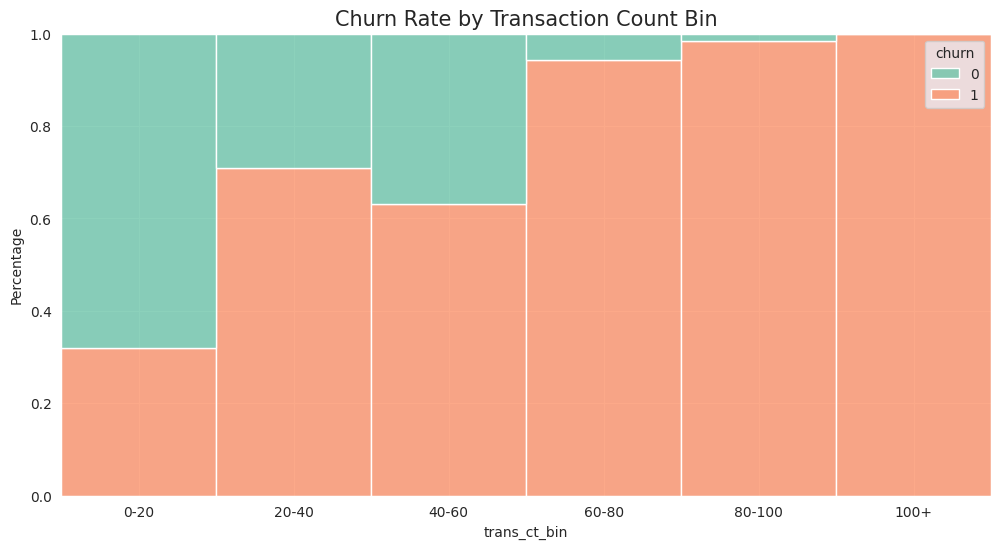

In [43]:
# 거래 횟수의 구간별 이탈율 시각화 (Stacked Bar)
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='trans_ct_bin', hue='churn', multiple='fill', palette='Set2').set_title('Churn Rate by Transaction Count Bin', fontsize=15)
plt.ylabel('Percentage')
plt.show()

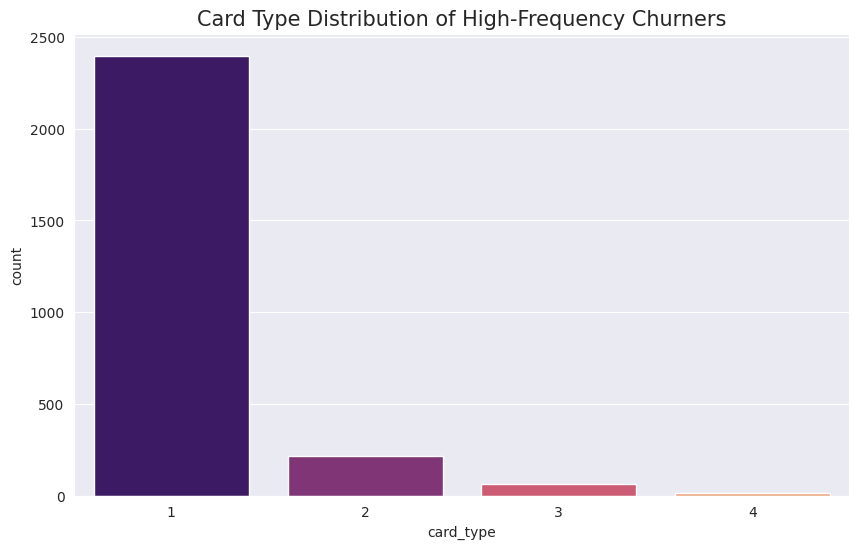

In [44]:
# 고빈도 이탈자(거래 횟수 80회 이상)
high_freq_churners = df[(df['transaction_count'] >= 80) & (df['churn'] == 1)]

# 이들의 카드 등급 분포 시각화
plt.figure(figsize=(10, 6))
sns.countplot(x='card_type', data=high_freq_churners, palette='magma').set_title('Card Type Distribution of High-Frequency Churners', fontsize=15)
plt.show()

Text(0.5, 1.0, 'Income Distribution of High-Frequency Churners')

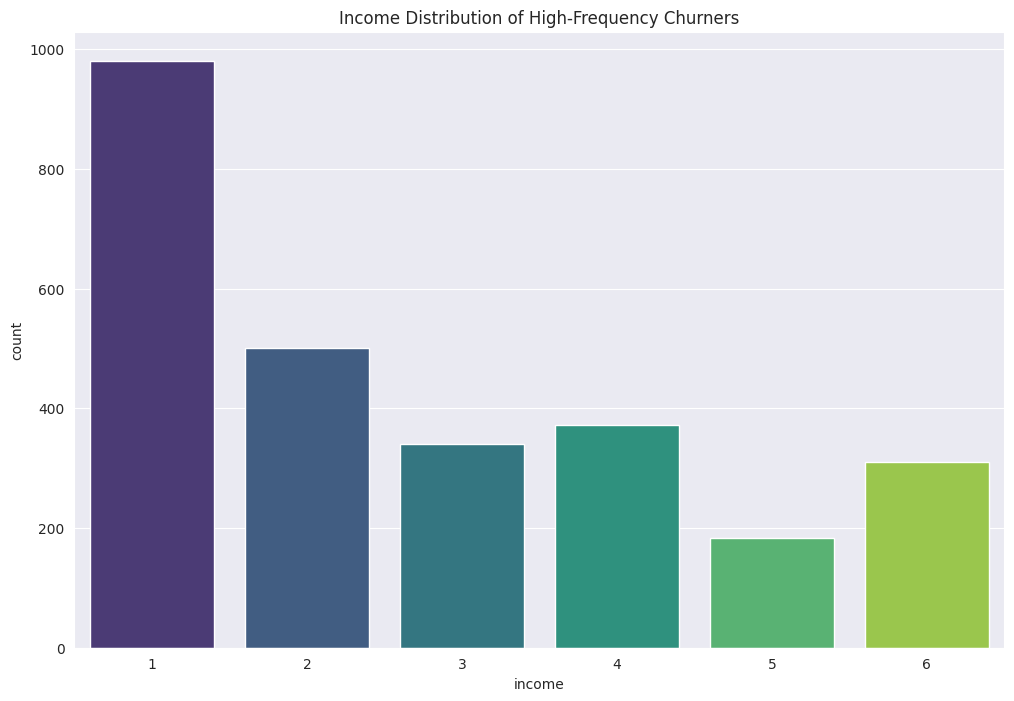

In [45]:
# 고빈도 이탈자의 소득 수준(income) 확인
# 만약 소득은 높은데 Blue 등급을 쓰다 나갔다면, 타겟 마케팅 실패의 증거입니다.
sns.countplot(x='income', data=high_freq_churners, palette='viridis').set_title('Income Distribution of High-Frequency Churners')

Text(0.5, 1.0, 'Transaction Count vs Amount by Churn Status')

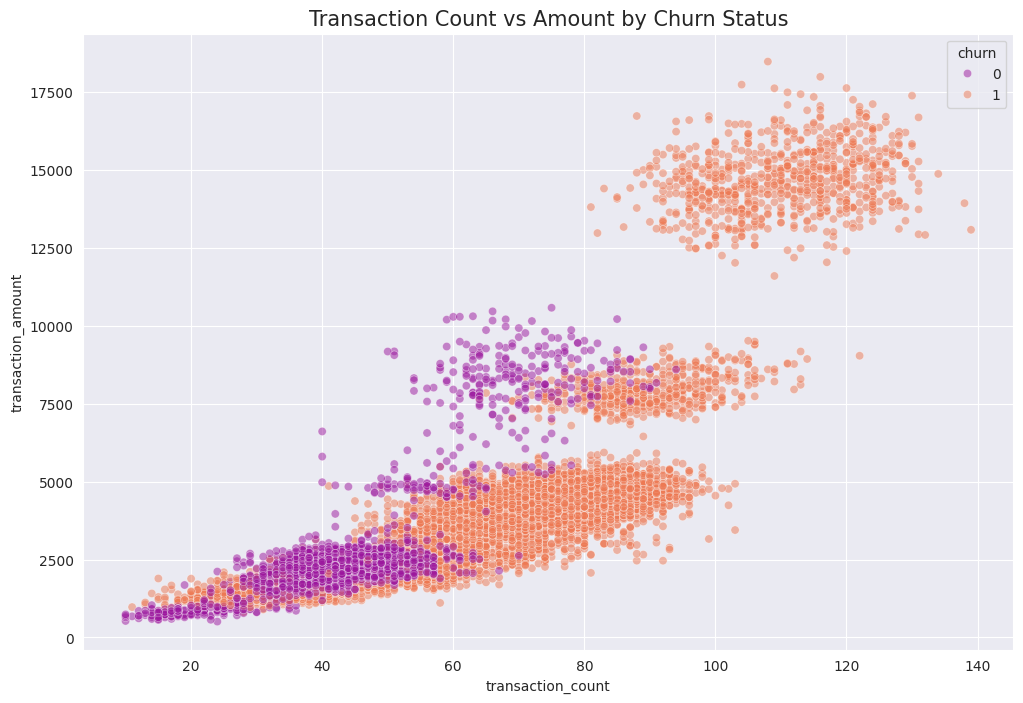

In [46]:
# 거래 횟수 vs 이용 금액 산점도
plt.figure(figsize=(12, 8)); sns.scatterplot(x='transaction_count', y='transaction_amount', hue='churn', data=df, palette='plasma', alpha=0.5).set_title('Transaction Count vs Amount by Churn Status', fontsize=15)

In [47]:
# 카드 등급별 한도 소진율
df.groupby('card_type')['utilization_ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
card_type,,,,,,,,
1,9436.0,0.290859,0.278635,0.0,0.02275,0.2070,0.52600,0.999
2,555.0,0.057310,0.050927,0.0,0.02150,0.0490,0.07950,0.234
3,116.0,0.057103,0.059939,0.0,0.02925,0.0505,0.07025,0.395
4,20.0,0.043650,0.033003,0.0,0.02250,0.0445,0.05525,0.141


In [48]:
# 건당 결제 금액 계산
df.assign(amt_per_it=df['transaction_amount']/df['transaction_count'])[['card_type', 'amt_per_it']].head()

,card_type,amt_per_it
0,1,27.238095
1,1,39.121212
2,1,94.350000
3,1,58.550000
4,1,29.142857


## 추가적인 심화 EDA

In [49]:
# 건당 평균 결제액(amt_per_it)과 이용 효율성(utilization_ratio는 기존 컬럼 활용)
df['amt_per_it'] = df['transaction_amount'] / df['transaction_count']
df[['amt_per_it', 'utilization_ratio']].describe()

,amt_per_it,utilization_ratio
count,10127.000000,10127.000000
mean,62.612717,0.274894
std,26.404198,0.275691
min,19.137931,0.000000
25%,47.514573,0.023000
50%,55.794872,0.176000
75%,65.476673,0.503000
max,190.193182,0.999000


분석 내용: 분석 내용: 총 결제 금액을 횟수로 나누어 고객의 소비 성향을 파악합니다.
소액 빈번 결제자와 고액 간헐 결제자의 이탈 패턴 차이를 확인하기 위한 기초 단계입니다.

Text(0.5, 1.0, 'Churn Rate by Inactive Months')

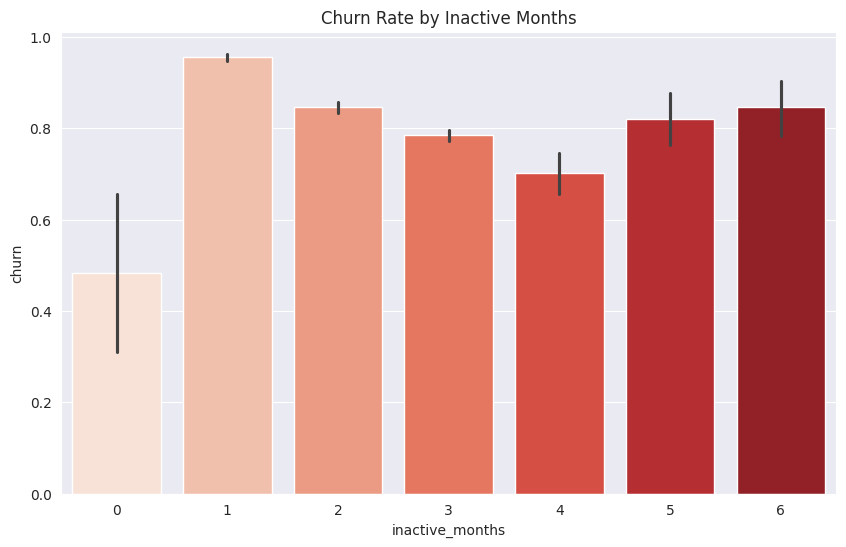

In [50]:
# 비활성 기간의 임계점 분석
plt.figure(figsize=(10, 6)); sns.barplot(x='inactive_months', y='churn', data=df, palette='Reds').set_title('Churn Rate by Inactive Months')

분석 내용: 카드를 사용하지 않은 기간이 길어질수록 이탈률(churn)이 어떻게 변하는지 분석합니다. 특정 개월 수(예: 3개월 이상)에서 이탈률이 급증한다면,
그 시점이 마케팅 개입의 '골든타임'이 됩니다.

Text(0.5, 1.0, 'Churn Rate by Relationship Months')

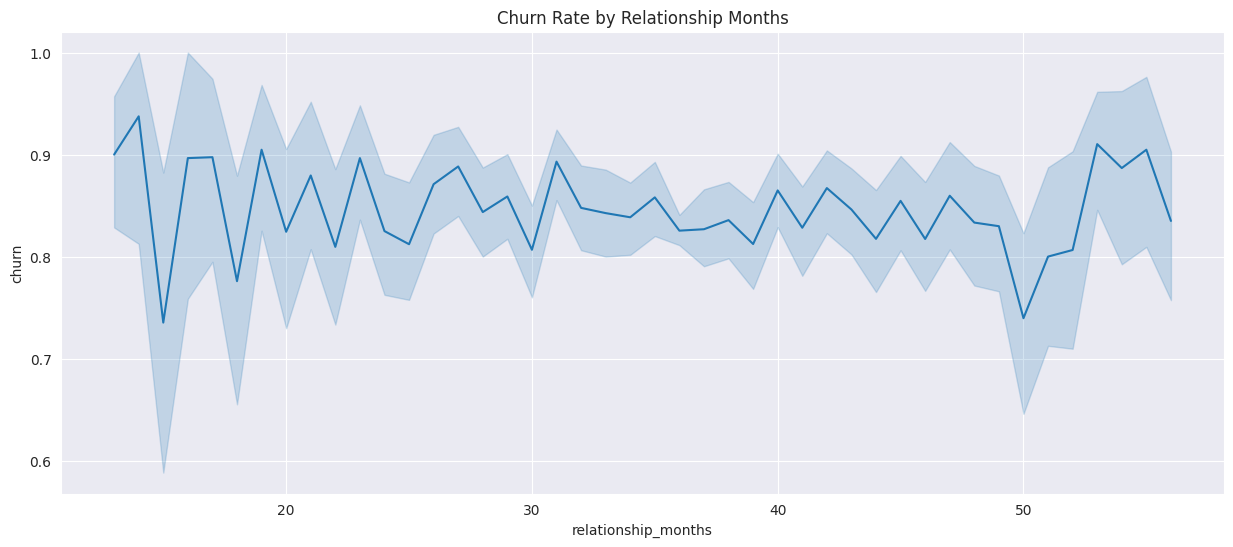

In [51]:
# 가입 기간별 이탈 민감도
plt.figure(figsize=(15, 6)); sns.lineplot(x='relationship_months', y='churn', data=df).set_title('Churn Rate by Relationship Months')

분석 내용: 신규 고객과 장기 고객 중 누가 더 이탈에 취약한지 확인합니다. 초기 적응 기간의 중요성이나 장기 고객의 충성도 변화 지점을 찾을 수 있습니다.

Text(0.5, 1.0, 'Churn Density by Transaction Count and Card Type')

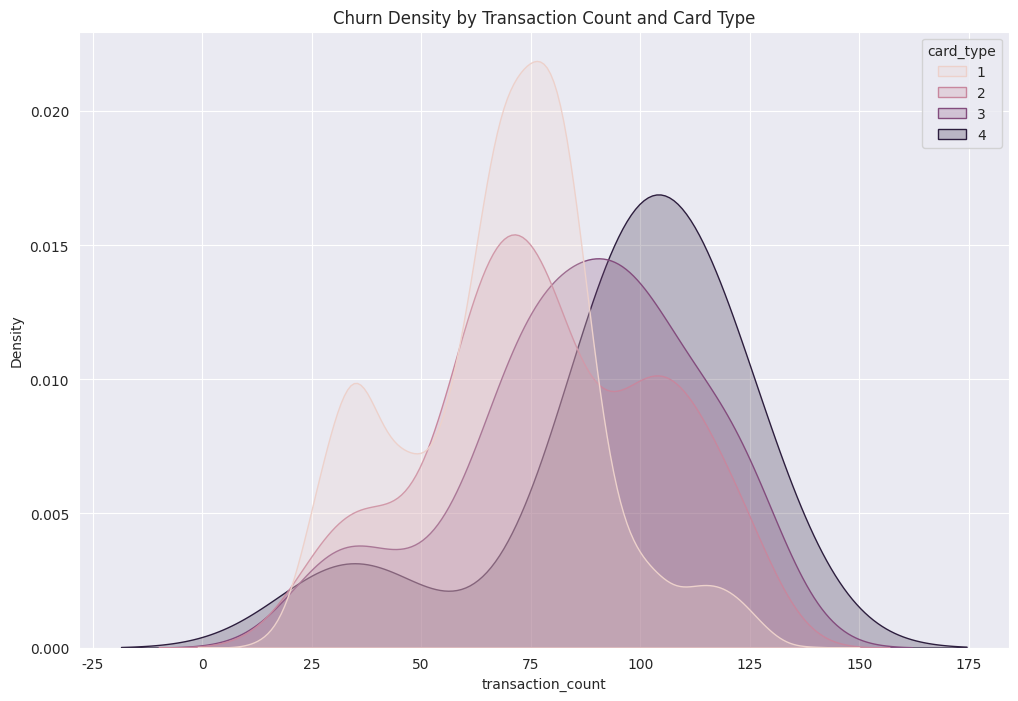

In [52]:
# 카드 등급별로 이탈률이 10% 이하로 떨어지는 거래 횟수 지점을 시각화로 확인
plt.figure(figsize=(12, 8)); sns.kdeplot(data=df, x='transaction_count', hue='card_type', weights='churn', fill=True, common_norm=False).set_title('Churn Density by Transaction Count and Card Type')

분석 내용: 각 카드 등급별로 고객이 '안정권'에 들어서는 거래 횟수 지점을 찾습니다. 이를 통해 등급별 유지 목표 수치를 다르게 설정하는 전략적 근거를 마련합니다.

In [53]:
# T-Test
from scipy import stats
# 이탈자(churn=1)와 유지자(churn=0) 간의 거래 횟수 평균 차이 검정
churn_0 = df[df['churn'] == 0]['transaction_count']
churn_1 = df[df['churn'] == 1]['transaction_count']

t_stat, p_val = stats.ttest_ind(churn_0, churn_1)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4e}")

T-statistic: -40.2507, P-value: 0.0000e+00


분석 내용: 시각화로 확인한 두 그룹 간의 차이가 단순한 우연인지 통계적으로 증명합니다.
P-value가 0.05 미만이면 두 그룹의 활동량 차이는 통계적으로 유의미하다고 보고서에 명시할 수 있습니다.